# RetailIQ · Dataset exploration

**Provenance: synthetic demonstration only.** No dataset was supplied. This notebook examines the reproducible fixture and establishes checks to repeat when actual transaction data is supplied. It does not describe a real FMCG market.

Questions: Is the line grain consistent? Does revenue translate into margin? Are customer and seasonal patterns sufficient to justify segmentation and forecasting?

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import matplotlib.pyplot as plt
root = Path.cwd() if (Path.cwd() / 'backend').exists() else Path.cwd().parent
sys.path.insert(0, str(root))
from backend.etl.pipeline import clean, profile
from backend.app.analytics.sales import overview, trend, aggregate
from backend.app.analytics.customers import rfm
raw = pd.read_csv(root / 'data/raw/synthetic_sales.csv')
sales, audit = clean(raw)
audit

{'input_rows': 21651,
 'output_rows': 21651,
 'exact_duplicates_removed': 0,
 'rejected_rows': 0,
 'source': ['synthetic']}

## Grain and data quality

Each row is a transaction line. Multiple lines can belong to one order, so counting rows would overstate purchase frequency and understate average order value. Missing costs cannot be imputed as zero because that would inflate profit. Invalid records block ingestion rather than disappearing silently.

In [2]:
report = profile(sales)
display(pd.DataFrame({'dtype':sales.dtypes.astype(str), 'missing':sales.isna().sum(), 'unique':sales.nunique()}))
print('Rows:', len(sales), 'Columns:', len(sales.columns), 'Exact duplicates:', raw.duplicated().sum())
print('Date coverage:', sales.date.min(), 'to', sales.date.max())
display(sales.select_dtypes('number').describe().T)
display(pd.Series(report['iqr_outliers'], name='IQR outliers'))

,dtype,missing,unique
line_id,string,0,21651
transaction_id,string,0,10826
date,datetime64[ns],0,1096
customer_id,string,0,600
product_id,string,0,10
product_name,string,0,10
brand,string,0,5
category,string,0,5
location_id,string,0,5
store,string,0,5


Rows: 21651 Columns: 23 Exact duplicates: 0
Date coverage: 2023-01-01 00:00:00 to 2025-12-31 00:00:00


,count,mean,std,min,25%,50%,75%,max
quantity,21651.0,4.010023,1.996704,1.0,2.0,4.0,6.0,7.0
unit_price,21651.0,111.009422,79.296463,25.0,45.0,60.0,180.0,260.0
unit_cost,21651.0,71.046030,50.749736,16.0,28.8,38.4,115.2,166.4
discount,21651.0,0.040599,0.066691,0.0,0.0,0.0,0.1,0.2
revenue,21651.0,428.632742,406.318272,20.0,140.0,270.0,594.0,1820.0
cost,21651.0,285.758921,269.402851,16.0,89.6,176.0,403.2,1164.8
profit,21651.0,142.873821,140.784850,4.0,45.0,88.2,194.4,655.2


quantity         0
unit_price       0
unit_cost        0
discount         0
revenue       1339
cost           915
profit        1402
Name: IQR outliers, dtype: int64

## Revenue, profit and regional mix

Gross profit is discounted revenue minus product cost; shipping, tax, labor and overhead are unavailable. It is not operating profit. Compare margins alongside revenue to avoid recommending high-volume but unprofitable activity.

revenue                9.280328e+06
profit                 3.093361e+06
units                  8.682100e+04
orders                 1.082600e+04
customers              6.000000e+02
average_order_value    8.572259e+02
margin_pct             3.333246e+01
repeat_purchase_pct    1.000000e+02
dtype: float64

,region,revenue,profit,units,orders,margin_pct
3,West,3760964.0,1253981.6,34896,4366,33.342026
2,South,1895951.5,633269.9,17592,2179,33.401166
1,North,1837835.5,613237.1,17404,2168,33.367355
0,East,1785576.5,592872.5,16929,2113,33.203422


,product_name,revenue,profit,units,orders,margin_pct
4,Filter Coffee,2130934.0,709878.0,8540,2011,33.312998
6,Laundry Liquid,1897038.0,634062.0,8970,2089,33.423790
5,Herbal Shampoo,1510740.0,503431.2,8744,2082,33.323484
3,Everyday Tea,1166074.0,388883.6,8674,2066,33.349822
2,Dishwash Gel,732492.0,243640.8,8487,2029,33.261906
9,Whole Milk,514176.0,171532.8,8923,2134,33.360717
0,Bath Soap,462643.5,153587.5,8780,2063,33.197808
1,Cultured Yogurt,376839.0,124666.2,8756,2081,33.082085
7,Oat Biscuits,287581.0,96621.0,8525,2022,33.597839
8,Salted Crisps,201810.0,67058.0,8422,1993,33.228284


,category,revenue,profit,units,orders,margin_pct
0,Beverages,3297008.0,1098761.6,17214,3872,33.326022
2,Home Care,2629530.0,877702.8,17457,3912,33.378695
3,Personal Care,1973383.5,657018.7,17524,3937,33.294020
1,Dairy,891015.0,296199.0,17679,4004,33.242875
4,Snacks,489391.0,163679.0,16947,3806,33.445445


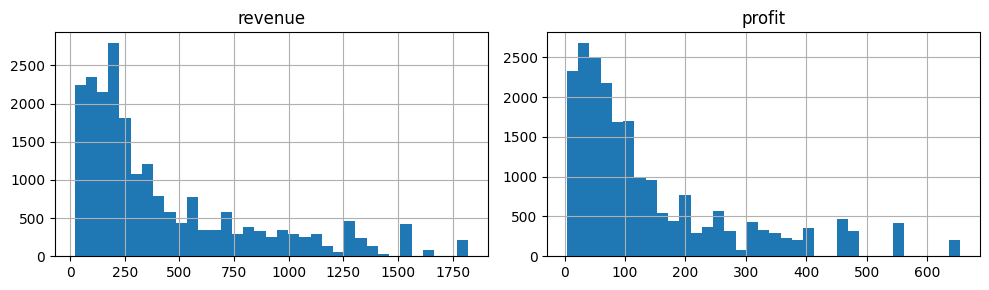

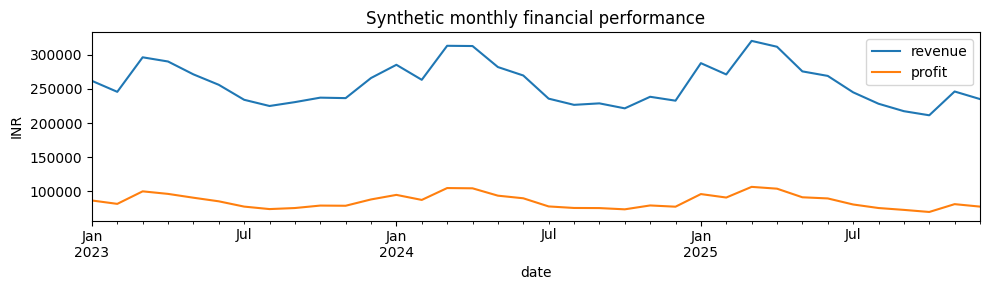

Observed fixture leader: West, revenue INR 3,760,964.00. This is a generated sample outcome.


In [3]:
display(pd.Series(overview(sales)))
display(aggregate(sales,'region'))
display(aggregate(sales,'product_name'))
display(aggregate(sales,'category'))
sales[['revenue','profit']].hist(bins=35, figsize=(10,3))
plt.tight_layout(); plt.show()
monthly = trend(sales)
monthly.plot(x='date', y=['revenue','profit'], figsize=(10,3), ylabel='INR', title='Synthetic monthly financial performance')
plt.tight_layout(); plt.show()
leader = aggregate(sales,'region').iloc[0]
print(f"Observed fixture leader: {leader['region']}, revenue INR {leader['revenue']:,.2f}. This is a generated sample outcome.")

## Customer distribution and segmentation suitability

The generator samples customers approximately uniformly. Real retail data often have stronger purchase concentration and inactivity. Consequently synthetic cluster quality must not be presented as evidence that segmentation will generalize to real customers. RFM labels are relative to this observation window, not proof of churn.

,customer_id,frequency,monetary,recency,r_score,f_score,m_score,segment
428,C0429,26,29938.0,12,5,5,5,Champions
491,C0492,20,29752.0,56,3,4,5,Loyal Customers
175,C0176,30,29513.5,9,5,5,5,Champions
130,C0131,29,28380.0,19,4,5,5,Champions
482,C0483,27,28031.5,44,3,5,5,Loyal Customers
470,C0471,30,27163.0,65,2,5,5,At Risk
85,C0086,31,27157.5,47,3,5,5,Loyal Customers
493,C0494,25,26607.5,8,5,5,5,Champions
363,C0364,27,26526.5,208,1,5,5,Lost Customers
388,C0389,25,26460.5,177,1,5,5,Lost Customers


segment
Potential Loyalists    161
Loyal Customers        152
Lost Customers         120
Champions               96
At Risk                 71
Name: count, dtype: int64

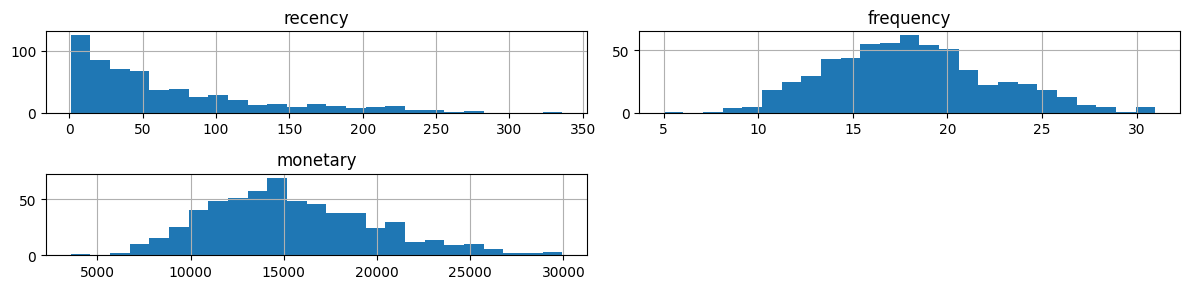

Top customer decile share of revenue: 15.7%


In [4]:
customers = rfm(sales)
display(customers.head(10))
display(customers.segment.value_counts())
customers[['recency','frequency','monetary']].hist(bins=25,figsize=(12,3))
plt.tight_layout(); plt.show()
top_share = customers.head(max(1,len(customers)//10)).monetary.sum()/customers.monetary.sum()
print(f'Top customer decile share of revenue: {top_share:.1%}')

## Promotions and next analytical steps

Discount assignment and product prices are generated. Units per line comparisons are descriptive, not causal lift. Evaluate forecasting chronologically against a moving-average baseline. Inspect anomaly candidates against the raw transactions and data-quality checks; no confirmed anomaly labels exist.

In [5]:
from backend.app.analytics.promotions import performance
display(performance(sales))
coverage = sales.groupby('product_name').agg(first=('date','min'),last=('date','max'),lines=('line_id','count'))
display(coverage)
print('Review partial boundary months before interpreting MoM/YoY; use full weeks for forecasting.')

,campaign,discount,lines,units,revenue,profit,units_per_line,margin_pct
0,Demo 10%,0.1,4382,17460,1775317.5,512869.5,3.984482,28.888889
1,Demo 20%,0.2,2204,8754,758200.0,151640.0,3.971869,20.000000
2,No promotion,0.0,15065,60607,6746810.0,2428851.6,4.023034,36.000000


,first,last,lines
product_name,,,
Bath Soap,2023-01-01,2025-12-30,2171
Cultured Yogurt,2023-01-01,2025-12-31,2192
Dishwash Gel,2023-01-01,2025-12-31,2142
Everyday Tea,2023-01-04,2025-12-31,2177
Filter Coffee,2023-01-01,2025-12-31,2109
Herbal Shampoo,2023-01-02,2025-12-31,2190
Laundry Liquid,2023-01-01,2025-12-31,2198
Oat Biscuits,2023-01-01,2025-12-31,2135
Salted Crisps,2023-01-01,2025-12-31,2091


Review partial boundary months before interpreting MoM/YoY; use full weeks for forecasting.
